# Phase 2: Multi-Class Classification Pipeline — KNN & Ensemble

This notebook implements the complete 10-class classification pipeline for the MNIST dataset.

**Required Improvements included:**
1. **Feature Engineering**: Using PCA (95% variance).
2. **Hyperparameter Tuning with Cross-Validation**: Implementing 3-Fold CV from scratch to find the best K.
3. **Learning Curves**: Plotting train vs validation accuracy to diagnose bias/variance tradeoff.
4. **Ensemble Methods**: Implementing a custom **Bagged KNN** ensemble classifier.
5. **Data Balancing**: Under-sampling all 10 classes to balance the dataset.


## 0. Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.features.mnist_features import load_mnist, split_data, normalize_data, build_features, class_distribution, balance_multi_classes
from src.analysis.evaluation import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from src.analysis.testing import evaluate_k_values, test_best_model
from src.models.knn_model import KNNClassifier, BaggedKNNClassifier

## 1. Load & Preprocess Data
We load the full 10-class MNIST dataset.

In [11]:
# Load the full MNIST dataset
x_all, y_all = load_mnist('../../data/mnist.npz')
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')
print('Class distribution:', class_distribution(y_all))

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Class distribution: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}


### 1.1 Train / Test Split & Normalization


In [3]:
# Split 80% train, 0% static val, 20% test
x_train, y_train, _, _, x_test, y_test = split_data(
    x_all, y_all, test_size=0.20, val_size=0.0, random_state=42
)
print(f'Train size: {len(y_train)} | Test size: {len(y_test)}')

# Balance the training data (Under-sampling)
print('\nBalancing multi-class training data...')
x_train, y_train = balance_multi_classes(x_train, y_train)
print(f'Balanced train size: {len(y_train)}')
print('Balanced distribution:', class_distribution(y_train))

# Normalize
x_train = normalize_data(x_train)
x_test  = normalize_data(x_test)


Train size: 56000 | Test size: 14000

Balancing multi-class training data...
Balanced train size: 50400
Balanced distribution: {0: 5040, 1: 5040, 2: 5040, 3: 5040, 4: 5040, 5: 5040, 6: 5040, 7: 5040, 8: 5040, 9: 5040}


## 2. Feature Extraction
We use PCA (retaining 95% variance) to make KNN computation feasible on the full 60k dataset.

In [4]:
# PCA Feature Extraction
# Note: val set is empty so we pass x_test as a dummy to avoid errors
train_f, _, test_f = build_features('pca', x_train, np.empty((0, 28, 28)), x_test, pca_components=0.95, random_state=42)
print(f'PCA features shape: {train_f.shape[1]} dimensions')

PCA features shape: 154 dimensions


## 3. Hyperparameter Tuning (Cross-Validation) & Learning Curves
We use 3-Fold Cross-Validation across K values to find the best K for standard KNN.

In [5]:
k_values = [1, 3, 5, 7, 9]
print('Running 3-Fold Cross-Validation...')
cv_results, best_k = evaluate_k_values(train_f, y_train, k_values=k_values, cv=3)

print(f'\nBest K = {best_k}')

Running 3-Fold Cross-Validation...
Evaluating KNN with k=1 using 3-Fold CV...
Evaluating KNN with k=3 using 3-Fold CV...
Evaluating KNN with k=5 using 3-Fold CV...
Evaluating KNN with k=7 using 3-Fold CV...
Evaluating KNN with k=9 using 3-Fold CV...

Best K = 1


### 3.1 Learning Curves (Bias/Variance Analysis)

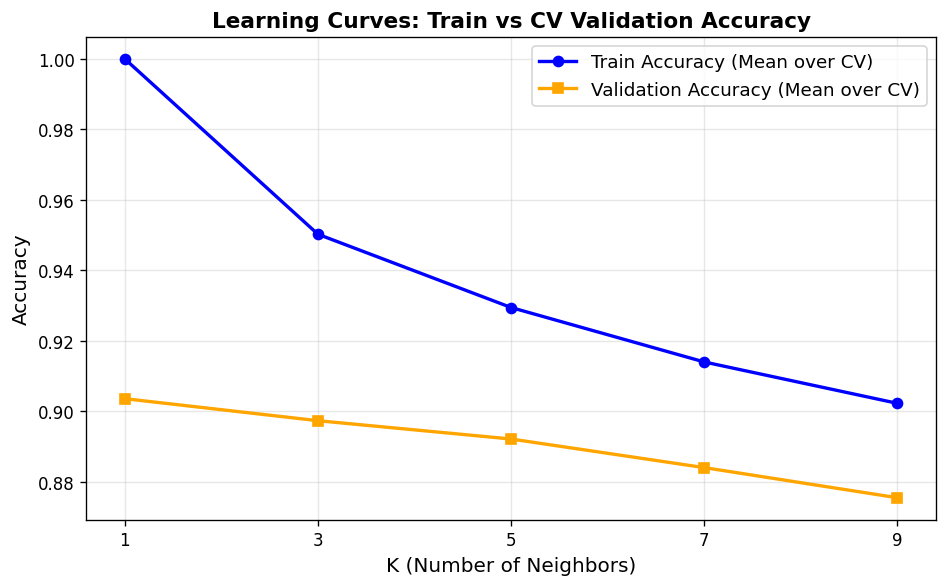

Analysis: Lower K (e.g., K=1) often shows high train accuracy (overfitting / low bias, high variance). As K increases, the model generalizes better, but too high K causes underfitting (high bias).


In [6]:
train_accs = [cv_results[k]['train_accuracy'] for k in k_values]
val_accs = [cv_results[k]['val_accuracy'] for k in k_values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, train_accs, 'o-', label='Train Accuracy (Mean over CV)', linewidth=2, color='blue')
ax.plot(k_values, val_accs, 's-', label='Validation Accuracy (Mean over CV)', linewidth=2, color='orange')

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curves: Train vs CV Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Analysis: Lower K (e.g., K=1) often shows high train accuracy (overfitting / low bias, high variance). As K increases, the model generalizes better, but too high K causes underfitting (high bias).')

## 4. Final Evaluation: Standard KNN vs Bagged Ensemble KNN
We train the best standard model and a new **Bagged Ensemble Model** to see if the ensemble improves performance.

In [7]:
print(f'\n--- Training Standard KNN (K={best_k}) ---')
final_model = KNNClassifier(k=best_k)
final_model.train(train_f, y_train)
std_results = test_best_model(final_model, test_f, y_test, average='macro')

print(f'\n--- Training Bagged KNN Ensemble (5 estimators, K={best_k}) ---')
bagged_model = BaggedKNNClassifier(n_estimators=5, k=best_k, max_samples=0.8)
bagged_model.train(train_f, y_train)
bagged_results = test_best_model(bagged_model, test_f, y_test, average='macro')

print('\n======= COMPARISON (Test Set) =======')
print(f'Standard KNN Accuracy: {std_results["accuracy"]:.4f} | F1: {std_results["f1_score"]:.4f}')
print(f'Bagged KNN Accuracy:   {bagged_results["accuracy"]:.4f} | F1: {bagged_results["f1_score"]:.4f}')


--- Training Standard KNN (K=1) ---
Testing best model on the test set...

--- Training Bagged KNN Ensemble (5 estimators, K=1) ---
Testing best model on the test set...
  Bagged Model 1/5 predicting...
  Bagged Model 2/5 predicting...
  Bagged Model 3/5 predicting...
  Bagged Model 4/5 predicting...
  Bagged Model 5/5 predicting...

======= COMPARISON (Test Set) =======
Standard KNN Accuracy: 0.9184 | F1: 0.9178
Bagged KNN Accuracy:   0.9127 | F1: 0.9124


### 4.1 Per-Class Accuracy (Recall) for the Best Model

In [8]:
best_results = bagged_results if bagged_results['accuracy'] > std_results['accuracy'] else std_results
pca = best_results['per_class_accuracy']

print('Accuracy (Recall) for each individual class:')
for label in sorted(pca.keys()):
    print(f'  Digit {label}: {pca[label]*100:.2f}%')

Accuracy (Recall) for each individual class:
  Digit 0: 97.99%
  Digit 1: 99.38%
  Digit 2: 89.42%
  Digit 3: 89.04%
  Digit 4: 90.04%
  Digit 5: 87.98%
  Digit 6: 96.92%
  Digit 7: 94.28%
  Digit 8: 80.25%
  Digit 9: 91.34%


### 4.2 Confusion Matrix (10x10)

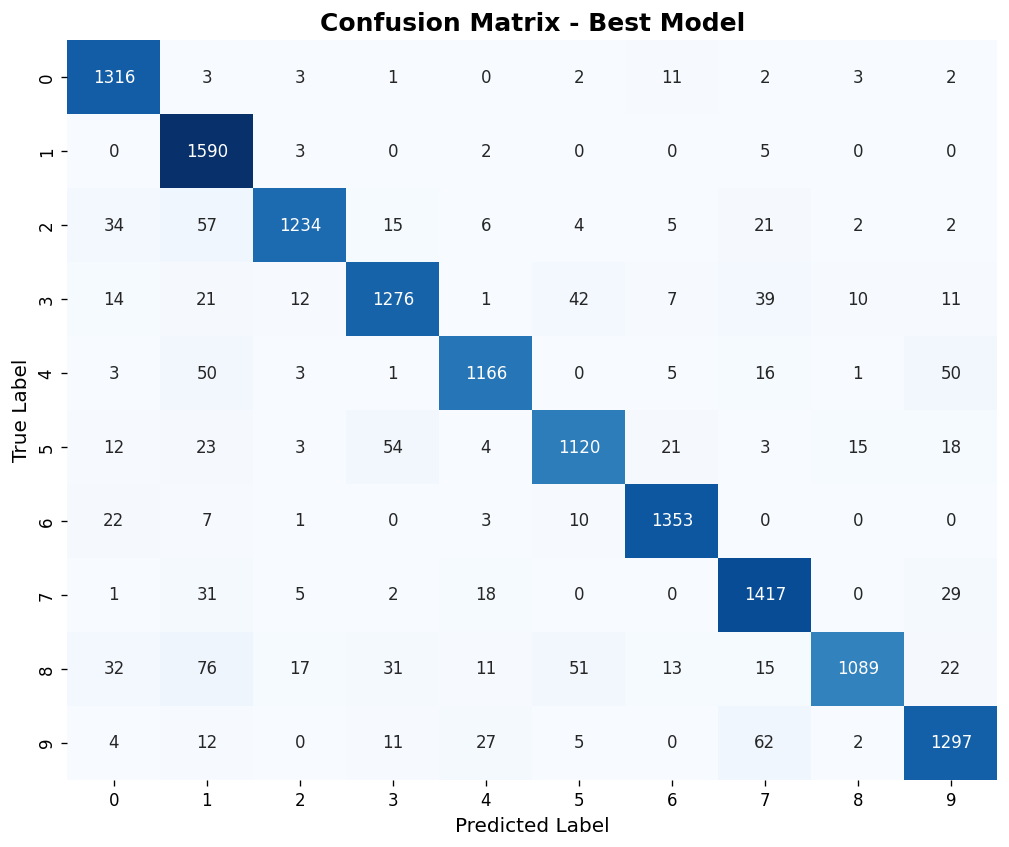

In [9]:
import seaborn as sns
cm = best_results['confusion_matrix']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Best Model', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()